# IPLACEX

## Basic Analysis

In [1]:
import pandas as pd

# Try reading the CSV file and check the columns
df = pd.read_csv('data/chats.csv', sep=',', on_bad_lines='skip', header=0, encoding='utf-8-sig')

# Count the number of unique session_ids (chats)
sessions = df['session_id'].nunique()
print(f"Number of chats: {sessions}")

# Count the number of unique messages
messages = df['message_id'].nunique()
print(f"Number of messages: {messages}")

# Average number of messages per session
avg_messages = messages / sessions
print(f"Average messages per session: {avg_messages:.2f}")

# Maximum number of messages in a session
max_messages = df['session_id'].value_counts().max()
print(f"Maximum messages in a session: {max_messages}")

# Identify sessions that contain administrative messages
sessions_with_admin = df[df['administrativa'] == 1]['session_id'].unique()
print(f"\n\nNumber of chats with administrative messages: {len(sessions_with_admin)}")

# Remove sessions that contain administrative messages
df_filtered = df[~df['session_id'].isin(sessions_with_admin)]

# Update statistics with the filtered dataset
sessions = df_filtered['session_id'].nunique()
print("\nStatistics after removing chats with administrative messages:")
print(f"Number of chats: {sessions}")

messages = df_filtered['message_id'].nunique()
print(f"Number of messages: {messages}")

avg_messages = messages / sessions
print(f"Average messages per session: {avg_messages:.2f}")

max_messages = df_filtered['session_id'].value_counts().max()
print(f"Maximum messages in a session: {max_messages}")

# Check df_filtered with sessions with number of messages > 1
df_filtered = df_filtered[df_filtered['session_id'].isin(df_filtered['session_id'].value_counts()[df_filtered['session_id'].value_counts() > 1].index)]
print(f"\n\nNumber of chats with more than 1 message: {df_filtered['session_id'].nunique()}")





Number of chats: 7906
Number of messages: 11059
Average messages per session: 1.40
Maximum messages in a session: 56


Number of chats with administrative messages: 4116

Statistics after removing chats with administrative messages:
Number of chats: 3790
Number of messages: 5441
Average messages per session: 1.44
Maximum messages in a session: 50


Number of chats with more than 1 message: 1473


## Analysis of the Course Chat Length

In [2]:
messages_per_session = df_filtered.groupby('session_id').size().reset_index(name='num_messages')

chat_sizes = df_filtered[['session_id', 'course_id']].drop_duplicates()
chat_sizes = chat_sizes.merge(messages_per_session, on='session_id')

course_stats = chat_sizes.groupby('course_id').agg({
    'num_messages': ['mean', 'max', 'count']
}).round(2)

# Rename columns for better readability
course_stats.columns = ['Average messages', 'Max messages', 'Number of chats']
course_stats = course_stats.sort_values(by='Average messages', ascending=False)

# Also show the top 20 courses with the highest average messages per chat
top_20_courses = course_stats.head(20)
print('\nTop 20 courses with highest average messages per chat:')
display(top_20_courses)

# Filter numbers of chats >  20
filtered_course_stats = course_stats[course_stats['Number of chats'] > 20]
print('\n\nCourses with more than  chats:')
display(filtered_course_stats)



Top 20 courses with highest average messages per chat:


,Average messages,Max messages,Number of chats
course_id,,,
PAC0923,12.17,36,6
CIES0324,12.00,12,1
ECO1004,10.67,50,6
CGE6004,10.00,10,1
PCX3002,7.50,8,2
PDR2002,7.25,14,4
PROC0923,6.83,21,6
POB0223,6.67,24,9
ADM3002,6.50,11,2




Courses with more than  chats:


,Average messages,Max messages,Number of chats
course_id,,,
CYR0124,4.48,14,21
TOP0523,4.12,18,32
DROG0124,3.83,28,23
PROG0323,3.76,14,25
FPR0123,3.70,13,27
ELE0523,3.68,13,25
SOP0123,3.64,11,25
MAT0001,3.52,15,84
MMP5008,3.30,11,23


###  Graph

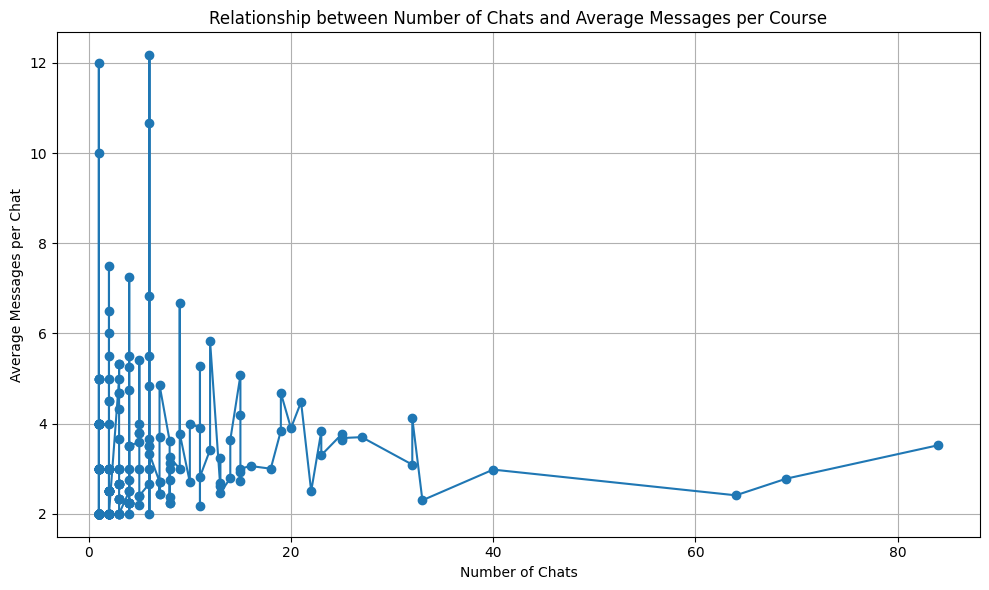

In [3]:
import matplotlib.pyplot as plt

# Sort by number of chats so the line plot makes sense
sorted_stats = course_stats.sort_values('Number of chats')

plt.figure(figsize=(10, 6))
plt.plot(sorted_stats['Number of chats'], sorted_stats['Average messages'], marker='o', linestyle='-')
plt.xlabel('Number of Chats')
plt.ylabel('Average Messages per Chat')
plt.title('Relationship between Number of Chats and Average Messages per Course')
plt.grid(True)
plt.tight_layout()
plt.show()